### **Post Lab Task**: Perform K-fold and Grid Search on Titanic Dataset.



1. BASELINE K-FOLD CROSS-VALIDATION
  Fold 1 Accuracy: 0.8156
  Fold 2 Accuracy: 0.7921
  Fold 3 Accuracy: 0.8202
  Fold 4 Accuracy: 0.8202
  Fold 5 Accuracy: 0.8258

Mean Baseline Accuracy: 0.8148 (± 0.0118)

2. GRID SEARCH TUNING
Tuned Best Model Fold Scores:
  Fold 1 Accuracy: 0.8268
  Fold 2 Accuracy: 0.8315
  Fold 3 Accuracy: 0.8258
  Fold 4 Accuracy: 0.8483
  Fold 5 Accuracy: 0.8596

Best Cross-Validation Accuracy: 0.8384

Best Parameters Found:
  max_depth: 8
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100

--- Out-of-Fold Classification Report ---
              precision    recall  f1-score   support

    Perished       0.84      0.91      0.87       549
    Survived       0.83      0.73      0.78       342

    accuracy                           0.84       891
   macro avg       0.84      0.82      0.82       891
weighted avg       0.84      0.84      0.84       891



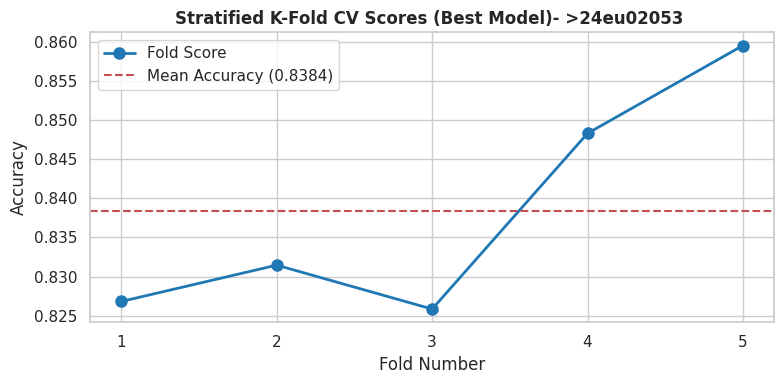

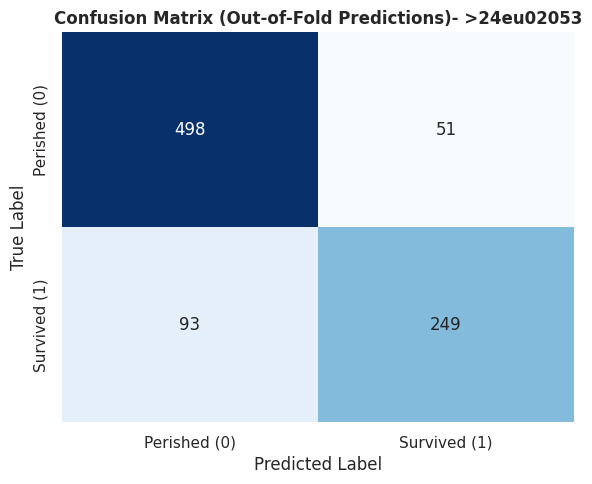

/tmp/ipykernel_748/2445511572.py:216: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")


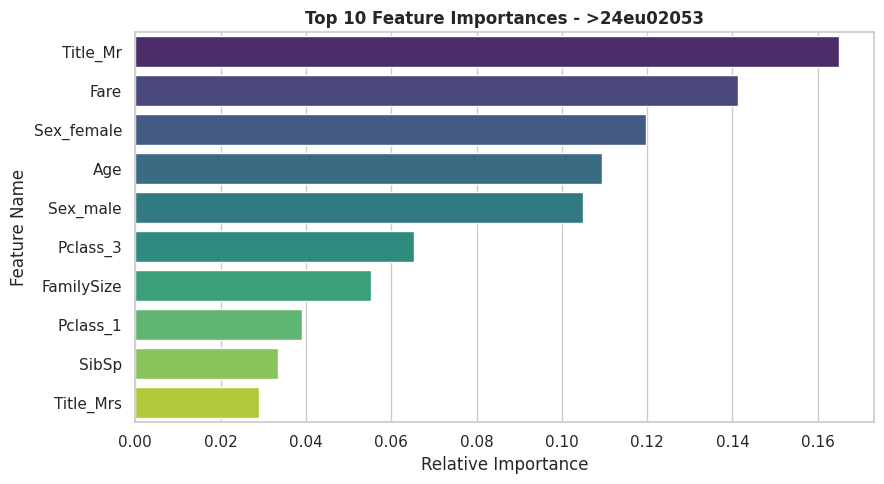

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Set visual style for plots
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATA & FEATURE ENGINEERING
# ==========================================
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(URL)

# Title Extraction
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df["Title"] = df["Title"].replace(
    [
        "Lady",
        "Countess",
        "Capt",
        "Col",
        "Don",
        "Dr",
        "Major",
        "Rev",
        "Sir",
        "Jonkheer",
        "Dona",
    ],
    "Rare",
).replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

# Family Features
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Feature Selection
num_features = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
cat_features = ["Pclass", "Sex", "Embarked", "Title", "IsAlone"]

X = df[num_features + cat_features]
y = df["Survived"]

# ==========================================
# 2. PREPROCESSING PIPELINES
# ==========================================
num_transformer = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

cat_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features),
    ]
)

# Set up Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)

# ==========================================
# 3. BASELINE K-FOLD CROSS-VALIDATION
# ==========================================
print("==========================================")
print("1. BASELINE K-FOLD CROSS-VALIDATION")
print("==========================================")

baseline_scores = cross_val_score(clf_pipeline, X, y, cv=skf, scoring="accuracy")

for fold_idx, score in enumerate(baseline_scores, 1):
    print(f"  Fold {fold_idx} Accuracy: {score:.4f}")

print(
    f"\nMean Baseline Accuracy: {baseline_scores.mean():.4f} (± {baseline_scores.std():.4f})"
)

# ==========================================
# 4. GRID SEARCH HYPERPARAMETER TUNING
# ==========================================
print("\n==========================================")
print("2. GRID SEARCH TUNING")
print("==========================================")

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [4, 6, 8],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    estimator=clf_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X, y)
best_model = grid_search.best_estimator_

# Retrieve individual fold scores for the tuned best model
best_model_fold_scores = [
    grid_search.cv_results_[f"split{i}_test_score"][grid_search.best_index_]
    for i in range(5)
]

print("Tuned Best Model Fold Scores:")
for fold_idx, score in enumerate(best_model_fold_scores, 1):
    print(f"  Fold {fold_idx} Accuracy: {score:.4f}")

print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
print("\nBest Parameters Found:")
for param, val in grid_search.best_params_.items():
    print(f"  {param.split('__')[1]}: {val}")

# Out-of-fold predictions and classification report
y_pred = cross_val_predict(best_model, X, y, cv=skf)

print("\n--- Out-of-Fold Classification Report ---")
print(classification_report(y, y_pred, target_names=["Perished", "Survived"]))

# ==========================================
# 5. VISUALIZATIONS
# ==========================================

# Figure 1: Stratified K-Fold Accuracy Scores Across Folds
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, 6),
    best_model_fold_scores,
    marker="o",
    linewidth=2,
    markersize=8,
    color="#1f77b4",
    label="Fold Score",
)
plt.axhline(
    y=np.mean(best_model_fold_scores),
    color="r",
    linestyle="--",
    label=f"Mean Accuracy ({np.mean(best_model_fold_scores):.4f})",
)
plt.title(
    "Stratified K-Fold CV Scores (Best Model)- >24eu02053 ", fontsize=12, fontweight="bold"
)
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: Confusion Matrix Heatmap
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Perished (0)", "Survived (1)"],
    yticklabels=["Perished (0)", "Survived (1)"],
)
plt.title(
    "Confusion Matrix (Out-of-Fold Predictions)- >24eu02053", fontsize=12, fontweight="bold"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Figure 3: Top Feature Importances
encoded_cat_cols = (
    best_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(cat_features)
)
feature_names = num_features + list(encoded_cat_cols)
importances = best_model.named_steps["classifier"].feature_importances_

feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 Feature Importances - >24eu02053", fontsize=12, fontweight="bold")
plt.xlabel("Relative Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()